# Domains labeling

When running `model.assign_domains`, the output domains are identified only by opaque IDs such as `D1003`, `L4`, and similar IDs. While sufficient for computation, these identifiers are difficult to interpret biologically.

In practice, it is often preferable to replace them with biologically meaningful annotations such as "Tertiary Lymphoid Structure" or "Necrotic Tumor".

This tutorial demonstrates a two-stage workflow for assigning interpretable domain names:

1. 🔁 Automated pre-annotation using an LLM (guided by extracted marker signals per domain).
2. 🧑‍💻 Biology-guided manual review (optional but recommended) to validate and refine the proposed labels.


In [1]:
import novae

## Get the spatial domains

Here, we assume you already ran `model.assign_domains`. If not, refer to the other tutorials, e.g. the [main usage tutorial](../main_usage) until you have your (unlabeled) spatial domains.

> For the sake of the tutorial, we load a dataset that was pre-annotated, see below.


In [2]:
adata = novae.load_dataset("Xenium_V1_hPancreas_Cancer_Add_on_FFPE_outs", annotations=True)[0]

[INFO] (novae.data._load._hf) Found 1 h5ad file(s) matching the filters.


Note that this `AnnData` object already contains the following keys in `adata.obs`:

- `cell_type` and `cell_type_level1`: a coarse and a detailed cell-type annotation (we used [scConcept](https://github.com/theislab/scConcept) and a [CELLxGENE](https://cellxgene.cziscience.com/) reference dataset).
- `novae_domains_res0.8` and `novae_domains_res1`: novae domains (unlabeled), obtained in zero-shot mode with a `resolution=0.8` and `resolution=1` respectively.


In [3]:
adata.obs.columns[-4:].tolist()

['cell_type', 'cell_type_level1', 'novae_domains_res0.8', 'novae_domains_res1']

We see the domains are named `L0` to `L7`. We would like to provide meaningful labels instead!


In [4]:
adata.obs["novae_domains_res1"].value_counts()

novae_domains_res1
L0    45299
L5    26733
L3    25777
L4    24055
L2    23553
L6    22224
L1    13647
L7     9666
Name: count, dtype: int64

## Automated labeling

You can use [`novae.label_domains`](../../api/label/#novae.label_domains) to generate a DataFrame mapping each domain ID to a domain label.

ℹ️ You may need extra dependencies to use this function: `openai` and/or `anthropic` and/or `python-dotenv`, depending on the arguments you use. Either install yourself the libs you'll need, or install them all via `pip install novae[llm]`.

### API key setup

An API key is required to use this function. You can either provide it directly as an `api_key` argument to [`novae.label_domains`](../../api/label/#novae.label_domains), or set it as an environment variable (`OPENAI_API_KEY` for OpenAI, `ANTHROPIC_API_KEY` for Anthropic).

> If you just want to generate the prompt without making an API call, set `return_prompt=True` and no API key will be required. You can then copy/paste the generated `messages` and `output_schema` into your preferred LLM playground.

For this example, we decided to load an `OPENAI_API_KEY` variable that we saved in a `.env` file:


In [2]:
import dotenv

dotenv.load_dotenv("./.env")

True

### LLM call

Then, we can actually run the labeling. Internally, it uses an LLM that is prompted with descriptive information: DEGs per domain, domain sizes, and optionally pathway expressions or cell-type proportions.

See more details in the [API](../../api/label/#novae.label_domains) on how to add pathway/cell-type information or LLM arguments.


In [6]:
df_labels = novae.label_domains(
    adata,
    "novae_domains_res1",  # the column in adata.obs containing the domain IDs to label
    tissue="pancreas-cancer",  # optional context (tissue or disease name)
    species="human",  # optional context (species name)
)

It creates a DataFrame with a label associated to each domain ID and a confidence score:


In [7]:
df_labels

,label,confidence_score
novae_domains_res1,,
L5,Reactive Stroma,0.95
L3,Peritumoral Immune Aggregate,0.92
L1,Desmoplastic Stroma,0.90
L6,Inflammatory Ductal Interface,0.92
L2,Ductal Tumor Region,0.89
L0,Acinar Cell Compartment,0.98
L4,Transitional Ductal Zone,0.88
L7,Endocrine Islet Niche,0.98


Afterwards, you can use this DataFrame to map each domain ID to the corresponding domain label:


In [8]:
adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

And plot the results:


/Users/quentinblampey/dev/novae/novae/plot/_spatial.py:78: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


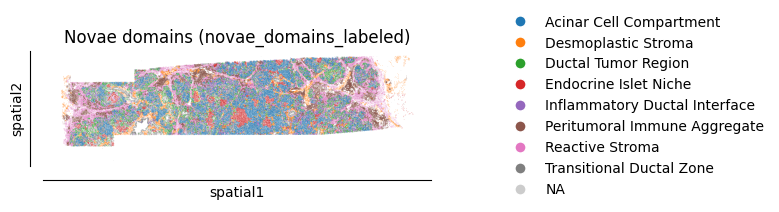

In [9]:
novae.plot.domains(adata, obs_key="novae_domains_labeled")

### Usage on multiple slides

If you have multiple slides, you still need to run `novae.label_domains` **only once**, since Novae was designed to retreive the same domains across slides.

Simply choose to run `novae.label_domains` on a representative slide (i.e., containing all domains), and then apply the `.map` for each slide.


In [ ]:
adatas = ...  # multiple AnnData / slides
adata_representative = ...  # on slide among the list

# run once (on the representative slide)
df_labels = novae.label_domains(adata_representative, "novae_domains_res1")

for adata in adatas:
    adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

## Manual review

We recommend to validate and refine the proposed labels. This requires biological knowledge, but allows a greater confidence in the resulting labels.

For the sake of the tutorial, we show it on another slide - as an extra example - but the steps apply to any slides / tissues.


In [8]:
adata = novae.load_dataset("Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE_outs", annotations=True)[0]

[INFO] (novae.data._load._hf) Found 1 h5ad file(s) matching the filters.


Here are the default (unlabed) domain IDs:


/Users/quentinblampey/dev/novae/novae/plot/_spatial.py:78: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


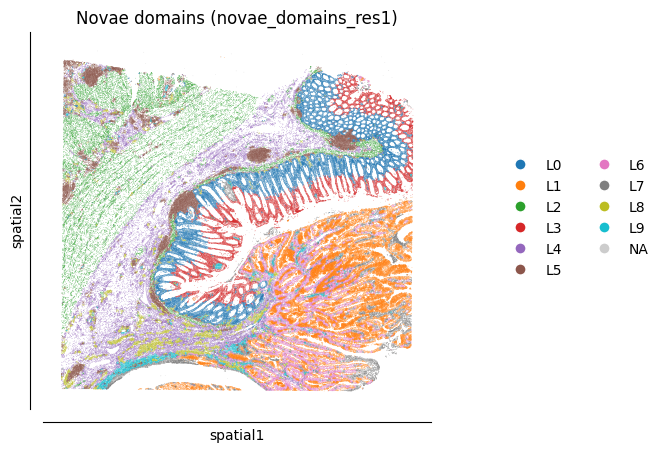

In [18]:
novae.plot.domains(adata, obs_key="novae_domains_res1")

We run the [automated labeling](../../api/label/#novae.label_domains) as a first step, as detailed above.


/Users/quentinblampey/dev/novae/novae/plot/_spatial.py:78: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


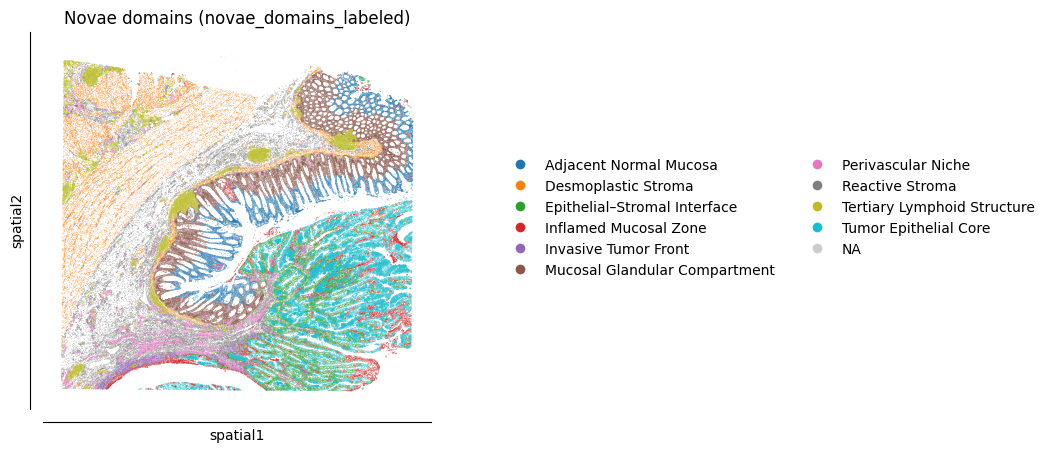

In [11]:
df_labels = novae.label_domains(
    adata,
    "novae_domains_res1",  # the column in adata.obs containing the domain IDs to label
    tissue="colorectal-cancer",  # optional context (tissue or disease name)
    species="human",  # optional context (species name)
    cell_type_key="cell_type_level1",  # optional column in adata.obs containing cell type annotations to use as additional context
)

adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

novae.plot.domains(adata, obs_key="novae_domains_labeled")

In [12]:
df_labels

,label,confidence_score
novae_domains_res1,,
L5,Tertiary Lymphoid Structure,0.94
L9,Invasive Tumor Front,0.87
L2,Desmoplastic Stroma,0.92
L4,Reactive Stroma,0.89
L8,Perivascular Niche,0.83
L0,Mucosal Glandular Compartment,0.97
L7,Inflamed Mucosal Zone,0.85
L1,Tumor Epithelial Core,0.98
L6,Epithelial–Stromal Interface,0.91


### Cell-type composition

Assuming you already ran cell-type annotation, one interesting thing to do is to check the cell-type composition of each domain.

On this dataset, we already ran cell-type annotation, and we have a column called `cell_type_level1`.

We can easily compute the cell-type proportion within each domain:


In [13]:
groups = adata.obs.groupby("novae_domains_res1", observed=True)
df_props = groups["cell_type_level1"].value_counts(normalize=True).unstack()

df_props

cell_type_level1,B and B plasma,Endothelial,Epithelial,Mesenchymal,Myeloid,Neural,T and NK cells
novae_domains_res1,,,,,,,
L0,0.141632,0.026559,0.717715,0.072249,0.031694,0.000884,0.009267
L1,0.002747,0.000655,0.993931,0.000878,0.000751,0.000000,0.001038
L2,0.094843,0.065708,0.032305,0.679914,0.079036,0.017351,0.030842
L3,0.117413,0.013672,0.803124,0.032026,0.028794,0.000083,0.004889
L4,0.096874,0.162963,0.027239,0.552982,0.124729,0.005747,0.029467
L5,0.389644,0.064428,0.061465,0.259155,0.101846,0.001140,0.122322
L6,0.036377,0.056368,0.750891,0.129122,0.021384,0.000000,0.005858
L7,0.061372,0.058181,0.653922,0.133423,0.084141,0.000061,0.008899
L8,0.351294,0.128712,0.057042,0.338283,0.089385,0.001911,0.033373


This can be visualized nicely via a heatmap:

> To better visualize the differences in proportions across domains, we scaled again the data, and set `vmin` and `vmax`.


<Axes: xlabel='cell_type_level1', ylabel='novae_domains_res1'>

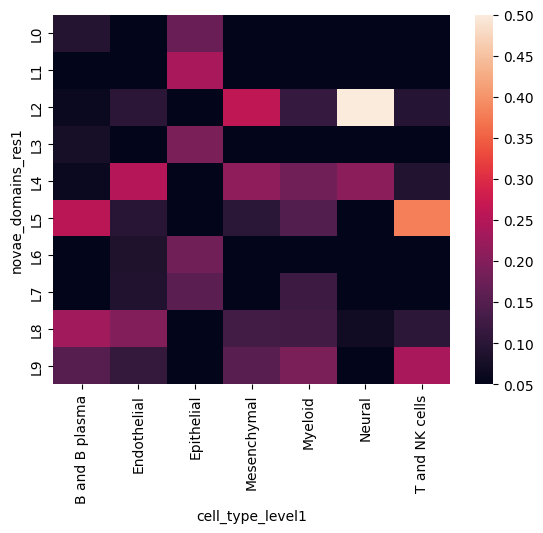

In [14]:
import seaborn as sns

sns.heatmap(df_props / df_props.sum(0), vmax=0.5, vmin=0.05)

### Marker genes

Extracting differentially expressed genes (DEGs) per domains also helps a lot in this manual review.


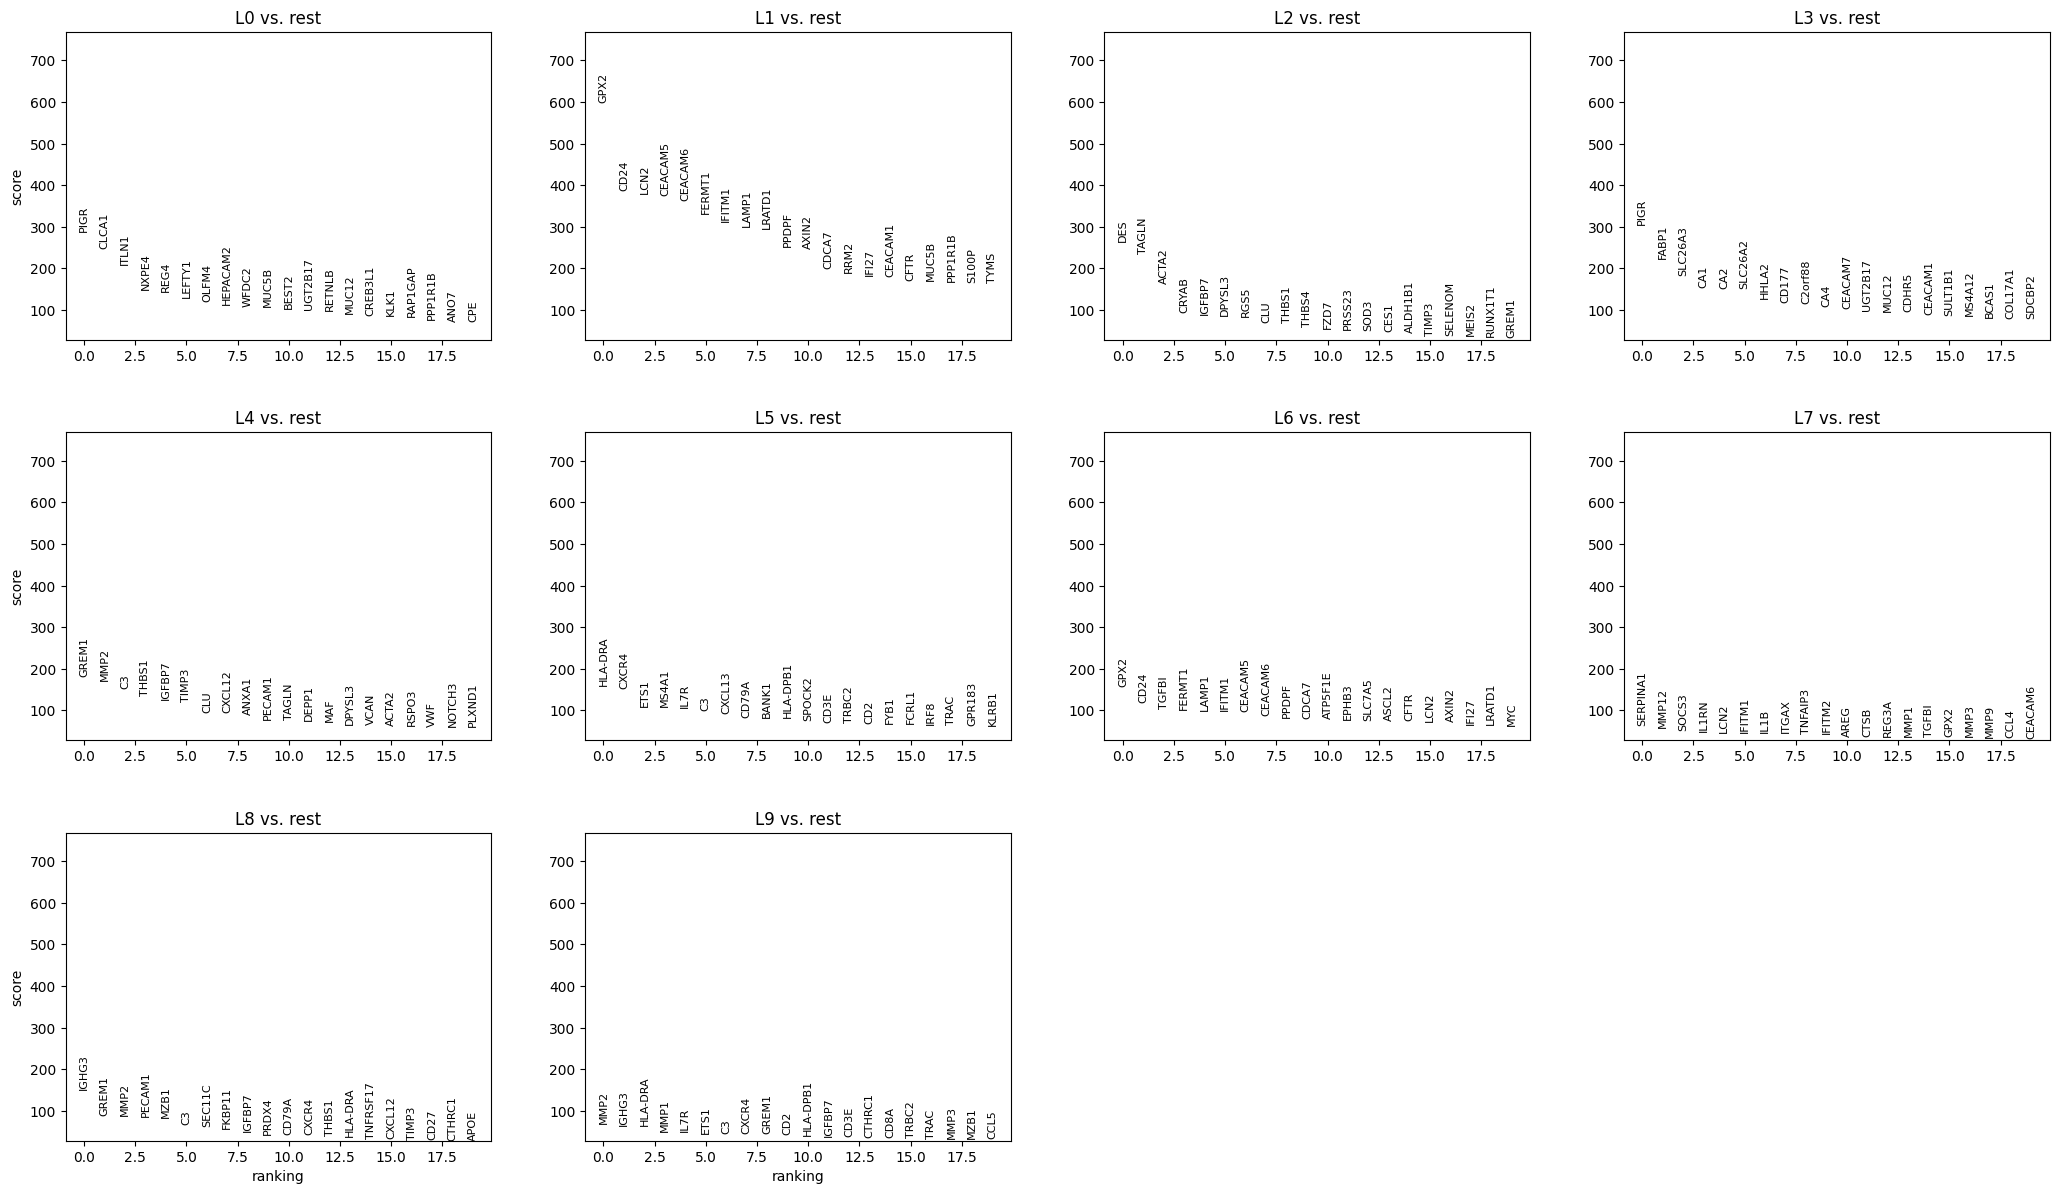

In [16]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, "novae_domains_res1")
sc.pl.rank_genes_groups(adata)

Or between two specific domains:


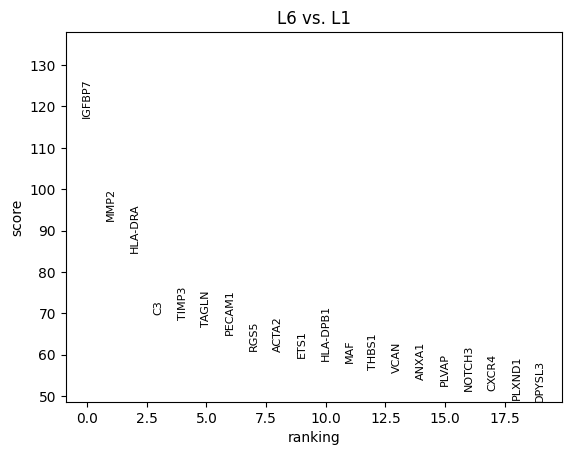

In [17]:
domain = "L6"
reference = "L1"

sc.tl.rank_genes_groups(adata, "novae_domains_res1", groups=[domain, reference], reference=reference)
sc.pl.rank_genes_groups(adata)

### Biological analysis

Based on the above plots, we can analyze the domains one by one:

- `L0`/`Mucosal Glandular Compartment`: Here the cell composition was limited to epithelium, so the LLM leveraged the markers (MUC family, REG4) to identify secretory activity. A better name would have been “Crypt base”.
- `L1`/`Tumor Epithelial Core` and `L6`/`Epithelial–Stromal Interface`: L1 vs L6 was not easy to distinguish because most of their signature overlap. But the LLM did a good job by emphasizing the epithelial nature of the tumor niche for L1, while putting more emphasis on the stromal proximity for L6 (“EMT invasive‑front niche” would have been a bit more accurate).
- `L2`/`Desmoplastic Stroma`: Not too bad, but it could have emphasized more on smooth muscle cells. This labeling would have been easier if the latter cell types were provided in the cell-type annotation.
- `L3`/`Adjacent Normal Mucosa`: Good use of metabolism markers (in particular fatty acid metabolism) to distinguish from the deeper part of the cript and identify the absorption function of the crypt apex.
- `L4`/`Reactive Stroma`: Here, the LLM was facing a complicated niche, with a mix of cell types (immune, neural and stromal) both in cell types and markers. He came up with a broad naming “Reactive Stroma” which is not too bad. He could have prioritize tissue knowledge to come up with “Lamina Propria”.
- `L5`/`Tertiary Lymphoid Structure`: Good identification of immune compartment from cells and signatures. He should have prioritize tissue knowledge to come up with “Peyer’s patches” or “GALT” which are the local equivalent of TLS in this tissue.
- `L7`/`Inflamed Mucosal Zone	`: Good identification of the immune component “inflammatory” stroma. But macrophage “innate immuno-supressive niche” would have been more accurate to emphasize the myeloïd signatures (IL1R, ITGAX, …) and the immunosupression of the response (AREG, TGF-B, …).
- `L8`/`Perivascular Niche`: Good labeling again, based on cellular proportions and signature.
- `L9`/`Invasive Tumor Front`: Also a good job here. This niche is a contact zone between healthy and tumor so kind of messy (lots of cells types and mixed signatures). The LLM accurately identified it as a transitional zone “Invasive Tumor Front” without over focusing on the immune or stromal aspect. This is very clear with the slide visualization, but way harder for the LLM as it does not have this vision.

ℹ️ This shows a convincing but not perfect labeling of the LLM. This labeling is also non-deterministic by default, and may lead to different results.
Providing more information (e.g., a precise and high-quality cell-type annotation) or pathway scores can help improve the labeling. See more details in the [API](../../api/label/#novae.label_domains) on how to provide this.


### Updating the labels

Based on our observations, we can update the label DataFrame using one or more of the following operations:

1. Rename a domain label if the current label is incorrect, ambiguous, or insufficiently specific.
2. Merge similar domains when two domains represent the same or highly overlapping concepts. This can be achieved by assigning both domains the same label.
3. Remove a domain label if the domain is too noisy, inconsistent, or difficult to categorize reliably (e.g., assign it to unknown, noisy, or NA).


In [19]:
### Renaming
df_labels.loc["L5", "label"] = "Peyer's patches"  # more specific than TLS here
df_labels.loc["L4", "label"] = "Lamina propria"  # better name for this domain
df_labels.loc["L0", "label"] = "Crypt base"  # better name for this domain

### Merge domains
# df_labels.loc["L3", "label"] = df_labels.loc["L0", "label"]

### Un-label a domain
# df_labels.loc["L7", "label"] = "unknown"

df_labels

,label,confidence_score
novae_domains_res1,,
L5,Peyer's patches,0.94
L9,Invasive Tumor Front,0.87
L2,Desmoplastic Stroma,0.92
L4,Lamina propria,0.89
L8,Perivascular Niche,0.83
L0,Crypt base,0.97
L7,Inflamed Mucosal Zone,0.85
L1,Tumor Epithelial Core,0.98
L6,Epithelial–Stromal Interface,0.91


And re-run the mapping from the original domain IDs:


/Users/quentinblampey/dev/novae/novae/plot/_spatial.py:78: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


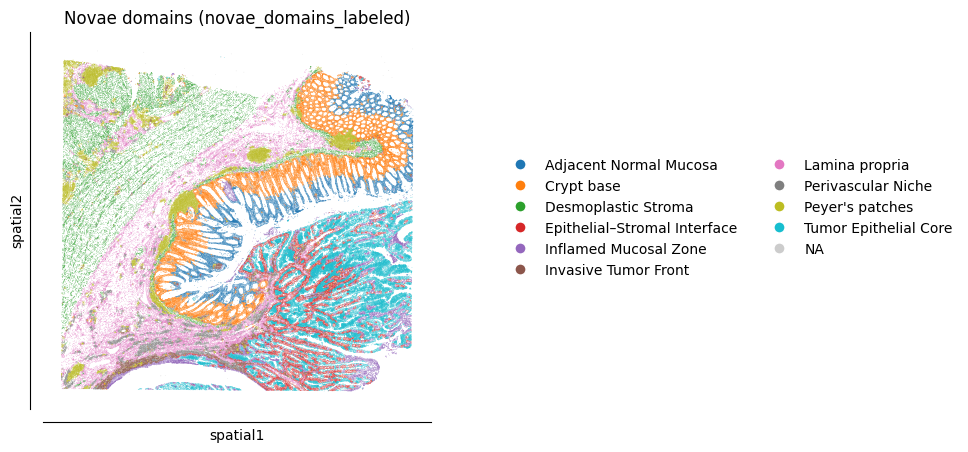

In [20]:
adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

novae.plot.domains(adata, obs_key="novae_domains_labeled")

### Other domain descriptions

The above domain descriptions are only examples; feel free to go further to characterize your domains better and cross-check them with the literature.


## Acknowledgment

Thanks to Lucas Rebuffet for reviewing the automated labeling and providing the biological insights from this tutorial.
